# TrailType Analysis and Visualization

This notebook analyzes performance metrics (Accuracy and Speed) grouped by `Condition` and `TrailTypeID`. It also provides 3D visualizations of the pen strokes.

In [17]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Set plot style
sns.set_theme(style="whitegrid")

# Configuration
BASE_PATH = "."
CONDITIONS = ['haptic', 'midair']

## 1. Data Classification and Loading

Load CSV files from 'haptic' and 'midair' folders, add a `Condition` column, and combine them.

In [18]:
def load_and_combine_data(base_path, conditions):
    all_data = []
    
    for condition in conditions:
        path = os.path.join(base_path, condition)
        if not os.path.exists(path):
            print(f"Warning: Path not found: {path}")
            continue
            
        files = glob.glob(os.path.join(path, "*.csv"))
        print(f"Found {len(files)} files in {condition}")
        
        for file in files:
            try:
                df = pd.read_csv(file)
                df['Condition'] = condition
                # Ensure File identifier is unique across folders if filenames overlap, 
                # though usually grouping by Condition covers it. Adding File column for safety.
                df['File'] = os.path.basename(file)
                all_data.append(df)
            except Exception as e:
                print(f"Error reading {file}: {e}")
    
    if not all_data:
        return pd.DataFrame()
        
    return pd.concat(all_data, ignore_index=True)

# Load Data
raw_df = load_and_combine_data(BASE_PATH, CONDITIONS)

if raw_df.empty:
    print("No data loaded. Please check the directory structure.")
else:
    print(f"Total rows loaded: {len(raw_df)}")
    print("Columns:", raw_df.columns.tolist())
    display(raw_df.head())

Found 10 files in haptic
Found 10 files in midair
Total rows loaded: 165229
Columns: ['Timestamp', 'Position_X', 'Position_Y', 'Position_Z', 'Rotation_X', 'Rotation_Y', 'Rotation_Z', 'IsTargetTrace', 'StrokeID', 'TargetID', 'TrailTypeID', 'DistToCenterline', 'Condition', 'File']


,Timestamp,Position_X,Position_Y,Position_Z,Rotation_X,Rotation_Y,Rotation_Z,IsTargetTrace,StrokeID,TargetID,TrailTypeID,DistToCenterline,Condition,File
0,0.000000,0.000824,0.073461,0.123689,88.88478,40.650630,134.52960,True,2,0,4,0.002012,haptic,1 h.csv
1,0.010649,0.000774,0.073392,0.123608,89.05105,30.571460,124.71410,True,2,0,4,0.001925,haptic,1 h.csv
2,0.023022,0.000803,0.073294,0.123671,89.17291,19.620190,113.96160,True,2,0,4,0.001985,haptic,1 h.csv
3,0.032755,0.000716,0.073238,0.123690,89.30677,5.063166,99.57462,True,2,0,4,0.001927,haptic,1 h.csv
4,0.044500,-0.000147,0.073062,0.123565,89.42189,319.813900,54.72952,True,2,0,4,0.001249,haptic,1 h.csv


## 2. Preprocessing

Filter for `IsTargetTrace` and calculate metrics per stroke.

In [19]:
def preprocess_data(df):
    if df.empty:
        return df
        
    # Filter for target traces
    if 'IsTargetTrace' in df.columns:
        target_df = df[df['IsTargetTrace'] == True].copy()
    else:
        print("Warning: 'IsTargetTrace' column not found. Using all data.")
        target_df = df.copy()

    # Verify required columns exist
    required_cols = ['Condition', 'TrailTypeID', 'StrokeID', 'File', 'DistToCenterline', 'Timestamp']
    missing = [c for c in required_cols if c not in target_df.columns]
    if missing:
        print(f"Error: Missing columns: {missing}")
        return pd.DataFrame()

    # Group by unique stroke identifier (Condition + File + StrokeID + TrailTypeID)
    # Grouping by TrailTypeID as well to ensure we carry it over to the aggregated result
    grouped = target_df.groupby(['Condition', 'File', 'StrokeID', 'TrailTypeID'])
    
    stroke_metrics = []
    
    for name, group in grouped:
        condition, file, stroke_id, trail_type = name
        
        # Calculate Duration
        duration = group['Timestamp'].max() - group['Timestamp'].min()
        
        # Calculate Mean Distance (Accuracy)
        mean_distance = group['DistToCenterline'].mean()
        
        stroke_metrics.append({
            'Condition': condition,
            'File': file,
            'StrokeID': stroke_id,
            'TrailTypeID': trail_type,
            'Duration': duration,
            'MeanDistance': mean_distance
        })
        
    return pd.DataFrame(stroke_metrics)

processed_df = preprocess_data(raw_df)

if not processed_df.empty:
    print(f"Total strokes processed: {len(processed_df)}")
    display(processed_df.head())

Total strokes processed: 560


,Condition,File,StrokeID,TrailTypeID,Duration,MeanDistance
0,haptic,1 h.csv,2,4,2.199129,0.001424
1,haptic,1 h.csv,3,2,6.697303,0.003250
2,haptic,1 h.csv,4,0,3.918430,0.002192
3,haptic,1 h.csv,5,6,2.721300,0.002829
4,haptic,1 h.csv,6,4,1.676910,0.001108


## 3. Statistical Analysis

Group by `Condition` and `TrailTypeID` to calculate Mean and Standard Deviation for `MeanDistance` (Accuracy) and `Duration` (Speed).

In [20]:
if not processed_df.empty:
    # Group by Condition and TrailTypeID
    group_cols = ['Condition', 'TrailTypeID']
    summary_stats = processed_df.groupby(group_cols)[['MeanDistance', 'Duration']].agg(['mean', 'std', 'count'])
    
    print("Summary Statistics (Mean & Std per Group):")
    display(summary_stats)
    
    # Optional: Save to CSV
    summary_stats.to_csv('statistical_summary.csv')
else:
    print("No processed data available for analysis.")

Summary Statistics (Mean & Std per Group):


MeanDistance                  Duration                
                              mean       std count      mean       std count
Condition TrailTypeID                                                       
haptic    0               0.003372  0.000923    35  4.395552  1.275826    35
          1               0.003987  0.000971    35  4.347342  1.195230    35
          2               0.004165  0.000916    35  7.767733  3.027573    35
          3               0.004578  0.001348    35  7.248940  2.039279    35
          4               0.002834  0.000829    35  2.415115  0.805305    35
          5               0.002745  0.001108    35  2.097732  0.751689    35
          6               0.004093  0.001898    35  3.297406  0.873257    35
          7               0.004632  0.001675    35  3.007784  0.892060    35
midair    0               0.004451  0.001535    35  2.347294  1.125098    35
          1               0.003932  0.000875    35  2.366366  1.078772    35
          2               0.004747  0.001905    35  3.768395  2.137525    35
          3               0.005218  0.002087    35  3.658736  1.555174    35
          4               0.003689  0.001433    35  1.285232  0.788902    35
          5               0.004393  0.001708    35  1.235985  0.586638    35
          6               0.004434  0.001578    35  1.831916  0.962750    35
          7               0.004890  0.001665    35  1.699846  0.830164    35

## 4. 2D Visualization: Grouped Bar Charts

Visualize Mean Distance and Duration with Error Bars, grouped by TrailTypeID and Hue=Condition.

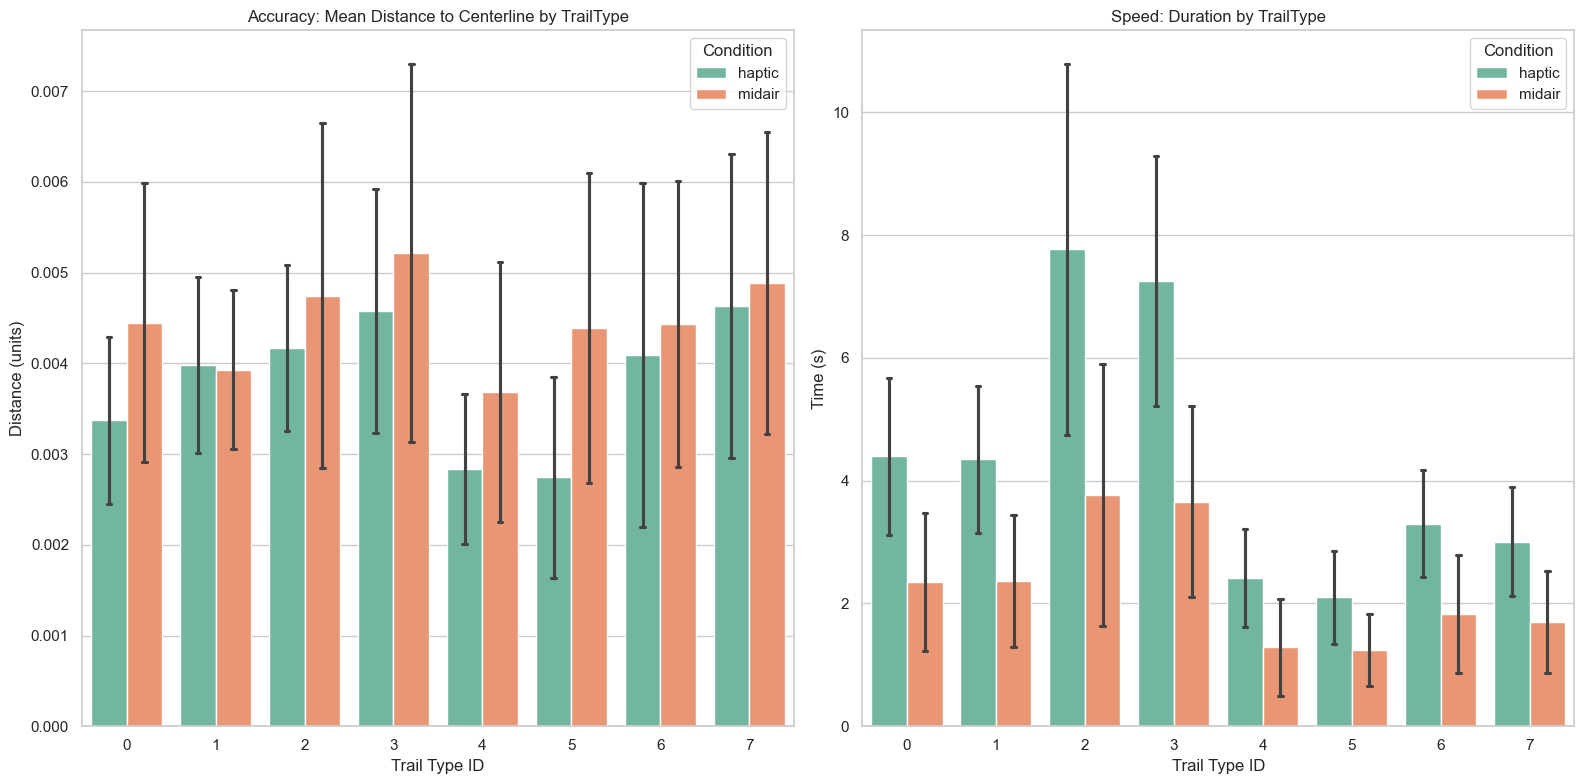

In [21]:
if not processed_df.empty:
    plt.figure(figsize=(16, 8))
    
    # Plot Mean Distance (Accuracy)
    plt.subplot(1, 2, 1)
    sns.barplot(
        x='TrailTypeID', 
        y='MeanDistance', 
        hue='Condition', 
        data=processed_df, 
        errorbar='sd',  # Show Standard Deviation as error bars
        capsize=.1, 
        palette="Set2"
    )
    plt.title('Accuracy: Mean Distance to Centerline by TrailType')
    plt.ylabel('Distance (units)')
    plt.xlabel('Trail Type ID')
    
    # Plot Duration (Speed)
    plt.subplot(1, 2, 2)
    sns.barplot(
        x='TrailTypeID', 
        y='Duration', 
        hue='Condition', 
        data=processed_df, 
        errorbar='sd', 
        capsize=.1, 
        palette="Set2"
    )
    plt.title('Speed: Duration by TrailType')
    plt.ylabel('Time (s)')
    plt.xlabel('Trail Type ID')
    
    plt.tight_layout()
    plt.show()
else:
    print("No processed data available for visualization.")

## 5. 3D and 2D Projection Visualization

Visualize the strokes in 3D space, separated by `TrailTypeID`. Points are color-coded by `Condition`.

- **3D Plots**: Interactive rotatable plots (if environment supports it) with equal axis scaling.
- **X-Y Plane Projections**: 2D scatter plots of X vs. Y coordinates to visualize the 'top' view of the trails.

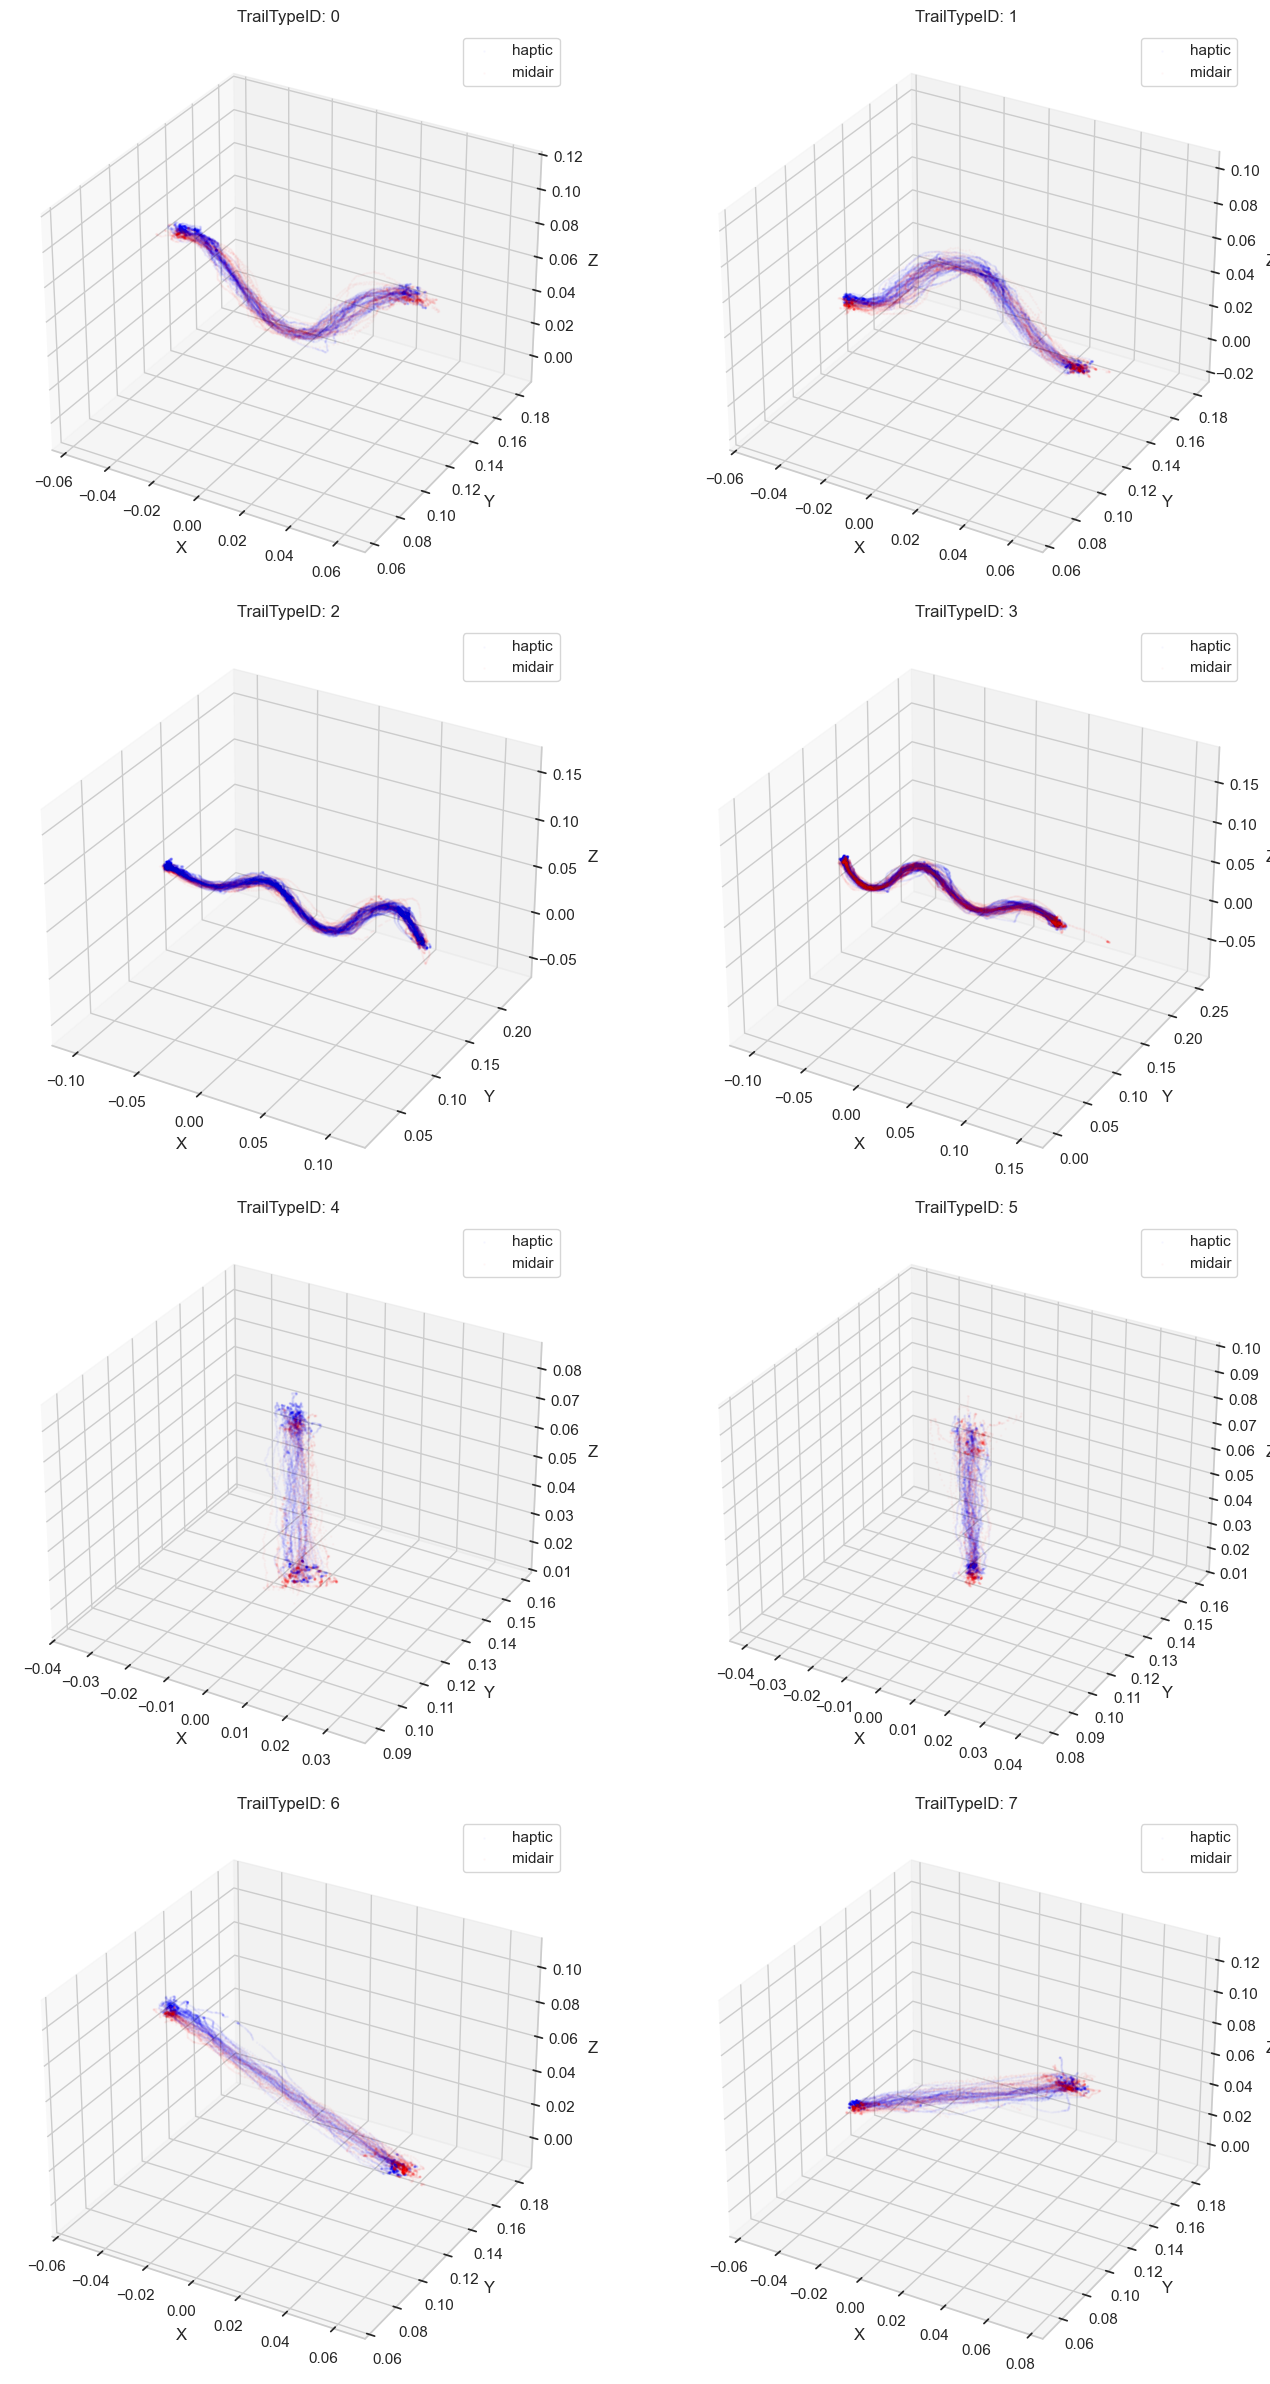

Generating X-Y Plane Projections...


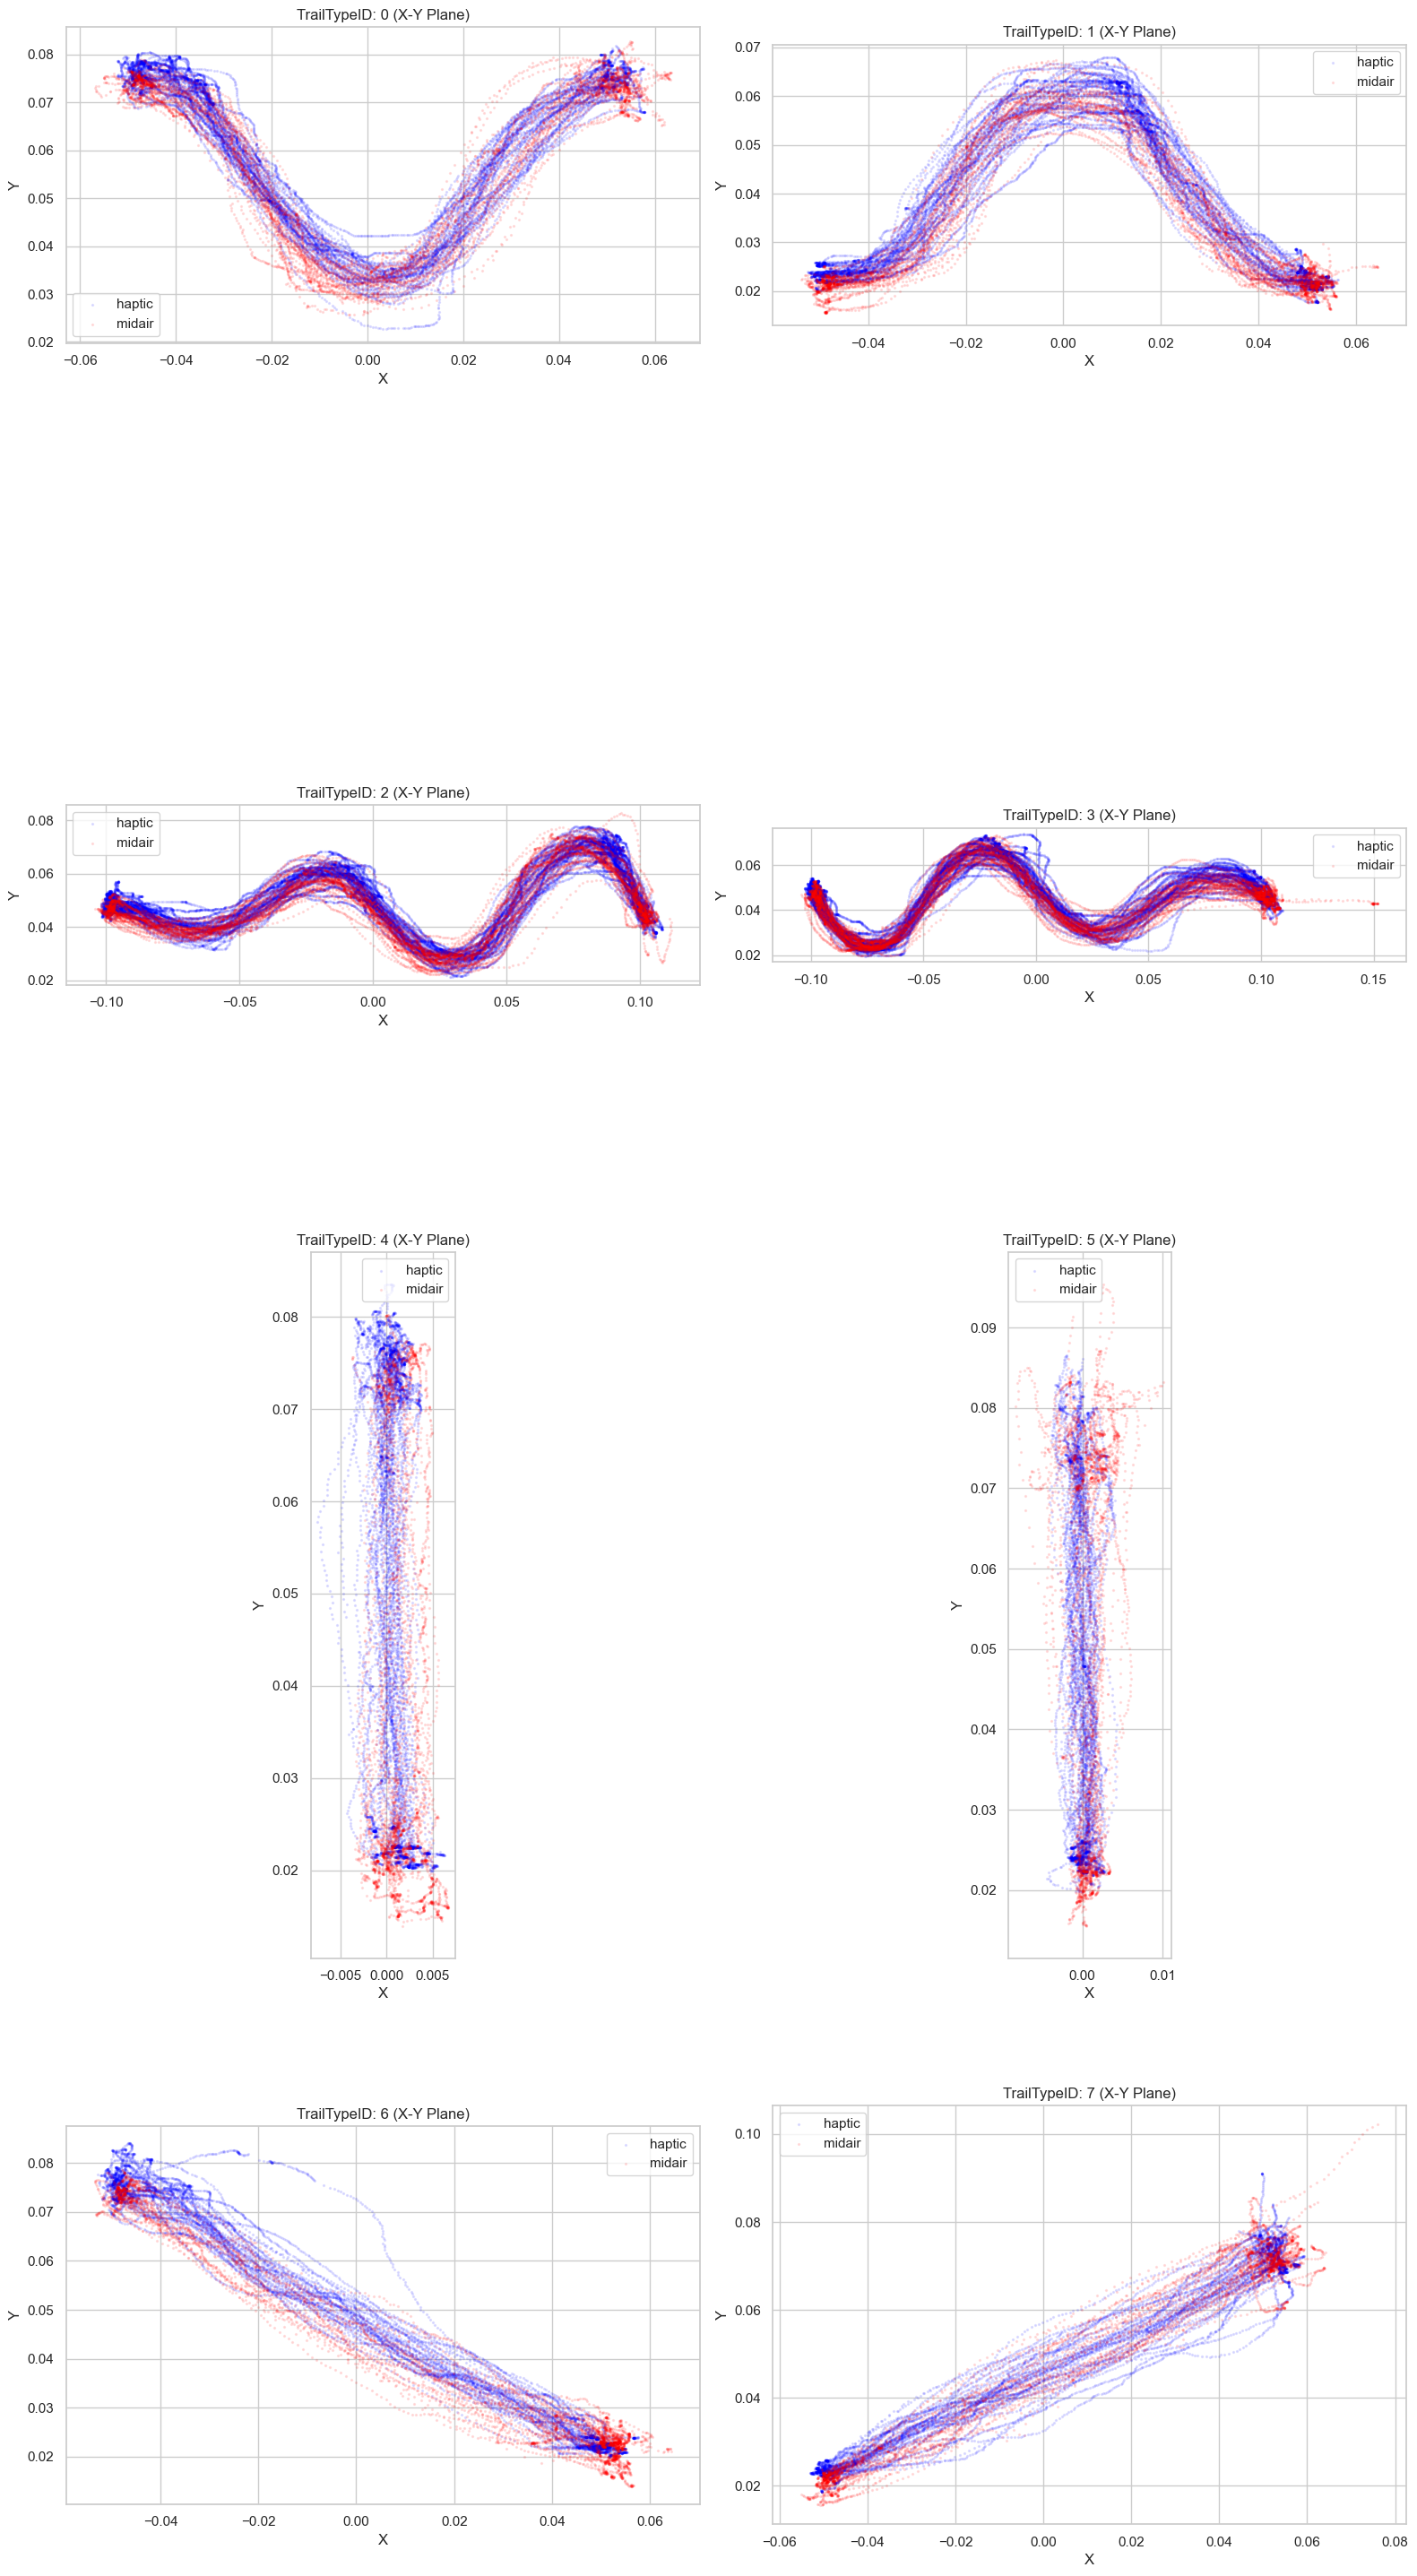

In [22]:
def plot_3d_trails(df, sample_rate=10):
    if df.empty:
        print("No data to plot.")
        return

    # Verify coordinate columns exist
    coord_cols = ['Position_X', 'Position_Y', 'Position_Z']
    if not all(col in df.columns for col in coord_cols):
        print(f"Error: Missing coordinate columns in raw data: {coord_cols}")
        return

    # Downsample to improve performance (plotting 10k+ points can be slow)
    plot_data = df.iloc[::sample_rate, :].copy()
    
    # Ensure we are plotting target traces only
    if 'IsTargetTrace' in plot_data.columns:
        plot_data = plot_data[plot_data['IsTargetTrace'] == True]

    # Get unique TrailTypeIDs
    trail_types = sorted(plot_data['TrailTypeID'].unique())
    
    # Setup subplots (e.g., 2 columns of plots)
    n_trails = len(trail_types)
    cols = 2
    rows = (n_trails + cols - 1) // cols
    
    fig = plt.figure(figsize=(15, 6 * rows))
    
    # Define colors for conditions
    colors = {'haptic': 'blue', 'midair': 'red'}

    for i, trail_id in enumerate(trail_types):
        ax = fig.add_subplot(rows, cols, i + 1, projection='3d')
        
        trail_subset = plot_data[plot_data['TrailTypeID'] == trail_id]
        
        for condition in CONDITIONS:
            subset = trail_subset[trail_subset['Condition'] == condition]
            if not subset.empty:
                ax.scatter(
                    subset['Position_X'], 
                    subset['Position_Z'], 
                    subset['Position_Y'], 
                    c=colors.get(condition, 'green'), 
                    s=1, 
                    alpha=0.02, 
                    label=condition
                )
        
        ax.set_title(f'TrailTypeID: {trail_id}')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        
        # Setting equal scale for 3D plot
        try:
            # Getting data limits
            x_limits = ax.get_xlim3d()
            y_limits = ax.get_ylim3d()
            z_limits = ax.get_zlim3d()

            x_range = abs(x_limits[1] - x_limits[0])
            x_middle = np.mean(x_limits)
            y_range = abs(y_limits[1] - y_limits[0])
            y_middle = np.mean(y_limits)
            z_range = abs(z_limits[1] - z_limits[0])
            z_middle = np.mean(z_limits)

            # The plot bounding box is a sphere in the sense of the infinity
            # norm, hence I call half the max range the plot radius.
            plot_radius = 0.5 * max([x_range, y_range, z_range])

            ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
            ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
            ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])
        except Exception as e:
            print(f"Could not set equal aspect ratio for 3D plot: {e}")
        
        ax.legend()

    plt.tight_layout()
    plt.show()
    
    # Create X-Y Plane Projections
    print("Generating X-Y Plane Projections...")
    fig_xy = plt.figure(figsize=(16, 8 * rows))
    
    for i, trail_id in enumerate(trail_types):
        ax_xy = fig_xy.add_subplot(rows, cols, i + 1)
        
        trail_subset = plot_data[plot_data['TrailTypeID'] == trail_id]
        
        for condition in CONDITIONS:
            subset = trail_subset[trail_subset['Condition'] == condition]
            if not subset.empty:
                ax_xy.scatter(
                    subset['Position_X'], 
                    subset['Position_Y'], 
                    c=colors.get(condition, 'green'), 
                    s=2, 
                    alpha=0.1, 
                    label=condition
                )
        
        ax_xy.set_title(f'TrailTypeID: {trail_id} (X-Y Plane)')
        ax_xy.set_xlabel('X')
        ax_xy.set_ylabel('Y')
        # Equal aspect ratio for 2D plot
        ax_xy.set_aspect('equal', 'box')
        ax_xy.legend()

    plt.tight_layout()
    plt.show()

if not raw_df.empty:
    plot_3d_trails(raw_df, sample_rate=1)

